# Substep Timing Analysis

This notebook visualizes detailed substep timing breakdowns for commit generation.

**Substeps measured:**
- Cache Lookup
- DB Load (BalanceInfo, BatchTree, Commitments)
- Initialize (for new accounts)
- Mutation (Hash + Tree Update)
- Cache Set

**Goal:** Identify which substep causes latency degradation over time.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [ ]:
# === CONFIGURE THIS ===
SUBSTEPS_FILE = "../../benchmark_output/tree_work_20260116_031006//bench_substeps_20260116_031009.csv"
DB_WRITES_FILE = "../../benchmark_output/tree_work_20260116_031006//bench_db_writes_20260116_031009.csv"  # Optional

# Time window for aggregation (seconds)
WINDOW_SECONDS = 5.0

# Warmup and cooldown periods to trim (seconds)
WARMUP_SECONDS = 30.0
COOLDOWN_SECONDS = 30.0
# ======================

## Load and Prepare Data

In [ ]:
def load_substeps(filepath, warmup_s, cooldown_s):
    """Load substep metrics and prepare for visualization."""
    df = pd.read_csv(filepath)

    # Convert timestamp to seconds
    df["timestamp_s"] = df["timestamp_ns"] / 1e9

    # Convert nanoseconds to milliseconds for readability
    ns_cols = [
        "cache_lookup_ns",
        "load_balance_info_ns",
        "load_batch_tree_ns",
        "load_commitments_ns",
        "db_load_total_ns",
        "init_ns",
        "hash_ns",
        "tree_update_ns",
        "mutation_total_ns",
        "cache_set_ns",
        "total_ns",
    ]
    for col in ns_cols:
        df[col.replace("_ns", "_ms")] = df[col] / 1e6

    # Optional derived columns (if tree-work signals exist)
    if "tree_updated_node_count" in df.columns:
        # Cost per updated node (ms/node). NaN when node_count == 0.
        df["tree_update_ms_per_node"] = np.where(
            df["tree_updated_node_count"] > 0,
            df["tree_update_ms"] / df["tree_updated_node_count"],
            np.nan,
        )

    # Trim warmup/cooldown
    min_time = df["timestamp_s"].min()
    max_time = df["timestamp_s"].max()
    start_time = min_time + warmup_s
    end_time = max_time - cooldown_s

    if start_time >= end_time:
        print(f"Warning: warmup + cooldown >= total duration. No data left.")
        return df.iloc[0:0]

    df = df[(df["timestamp_s"] >= start_time) & (df["timestamp_s"] <= end_time)].copy()
    df["time_normalized"] = df["timestamp_s"] - start_time

    return df

# Load data
df = load_substeps(SUBSTEPS_FILE, WARMUP_SECONDS, COOLDOWN_SECONDS)
print(f"Loaded {len(df)} substep records")
print(f"Cache hit rate: {df['cache_hit'].mean() * 100:.2f}%")
print(f"Duration: {df['time_normalized'].max():.1f} seconds")

Loaded 12868525 substep records
Cache hit rate: 52.90%
Duration: 547.0 seconds


In [ ]:
def aggregate_by_window(df, time_col, window_s, value_cols, agg_func="mean"):
    """Aggregate data by time window."""
    if df.empty:
        return pd.DataFrame()
    
    df = df.copy()
    df["window"] = (df[time_col] // window_s).astype(int)
    df["window_start"] = df["window"] * window_s
    
    if agg_func == "mean":
        result = df.groupby("window_start")[value_cols].mean().reset_index()
    elif agg_func == "median":
        result = df.groupby("window_start")[value_cols].median().reset_index()
    elif agg_func == "p95":
        result = df.groupby("window_start")[value_cols].quantile(0.95).reset_index()
    else:
        result = df.groupby("window_start")[value_cols].agg(agg_func).reset_index()
    
    return result

## Total Latency Over Time

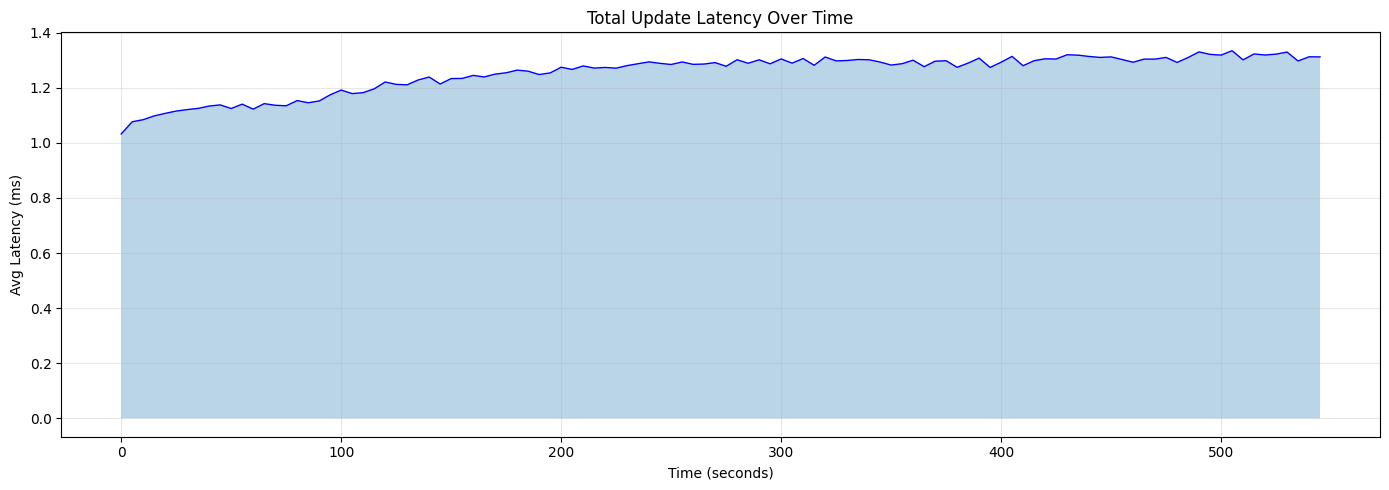

In [ ]:
# Total latency over time
agg = aggregate_by_window(df, "time_normalized", WINDOW_SECONDS, ["total_ms"])

plt.figure(figsize=(14, 5))
plt.plot(agg["window_start"], agg["total_ms"], 'b-', linewidth=1)
plt.fill_between(agg["window_start"], agg["total_ms"], alpha=0.3)
plt.xlabel("Time (seconds)")
plt.ylabel("Avg Latency (ms)")
plt.title("Total Update Latency Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Substep Breakdown Over Time (Stacked Area)

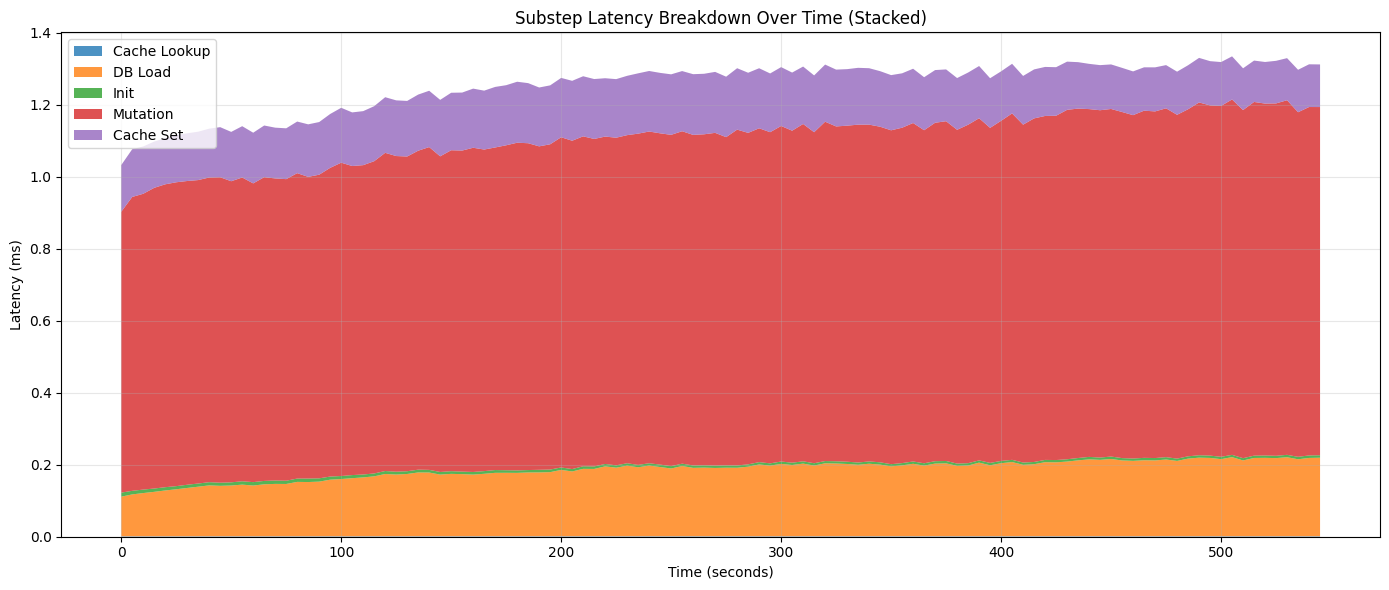

In [ ]:
# Stacked area chart of substep breakdown
substep_cols = ["cache_lookup_ms", "db_load_total_ms", "init_ms", "mutation_total_ms", "cache_set_ms"]
agg = aggregate_by_window(df, "time_normalized", WINDOW_SECONDS, substep_cols)

plt.figure(figsize=(14, 6))
plt.stackplot(agg["window_start"], 
              agg["cache_lookup_ms"], 
              agg["db_load_total_ms"], 
              agg["init_ms"],
              agg["mutation_total_ms"], 
              agg["cache_set_ms"],
              labels=["Cache Lookup", "DB Load", "Init", "Mutation", "Cache Set"],
              alpha=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Latency (ms)")
plt.title("Substep Latency Breakdown Over Time (Stacked)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Individual Substep Latencies Over Time

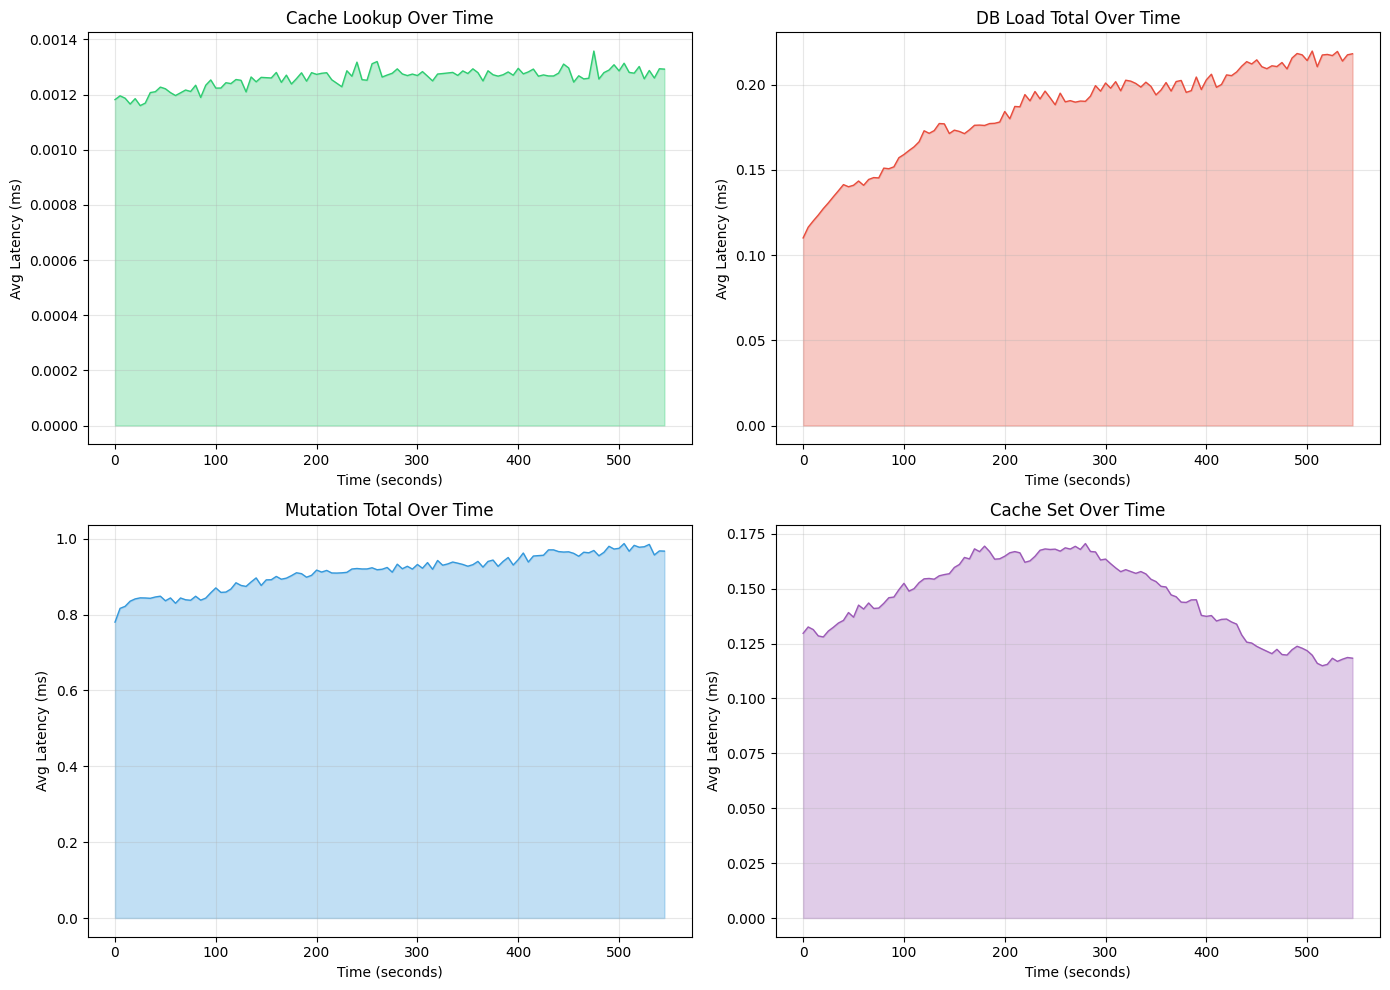

In [ ]:
# Individual substep plots
substeps = [
    ("cache_lookup_ms", "Cache Lookup", "#2ecc71"),
    ("db_load_total_ms", "DB Load Total", "#e74c3c"),
    ("mutation_total_ms", "Mutation Total", "#3498db"),
    ("cache_set_ms", "Cache Set", "#9b59b6"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col, title, color) in enumerate(substeps):
    agg = aggregate_by_window(df, "time_normalized", WINDOW_SECONDS, [col])
    axes[idx].plot(agg["window_start"], agg[col], color=color, linewidth=1)
    axes[idx].fill_between(agg["window_start"], agg[col], alpha=0.3, color=color)
    axes[idx].set_xlabel("Time (seconds)")
    axes[idx].set_ylabel("Avg Latency (ms)")
    axes[idx].set_title(f"{title} Over Time")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## DB Load Breakdown (BalanceInfo, BatchTree, Commitments)

Cache misses: 6061615 (47.10%)


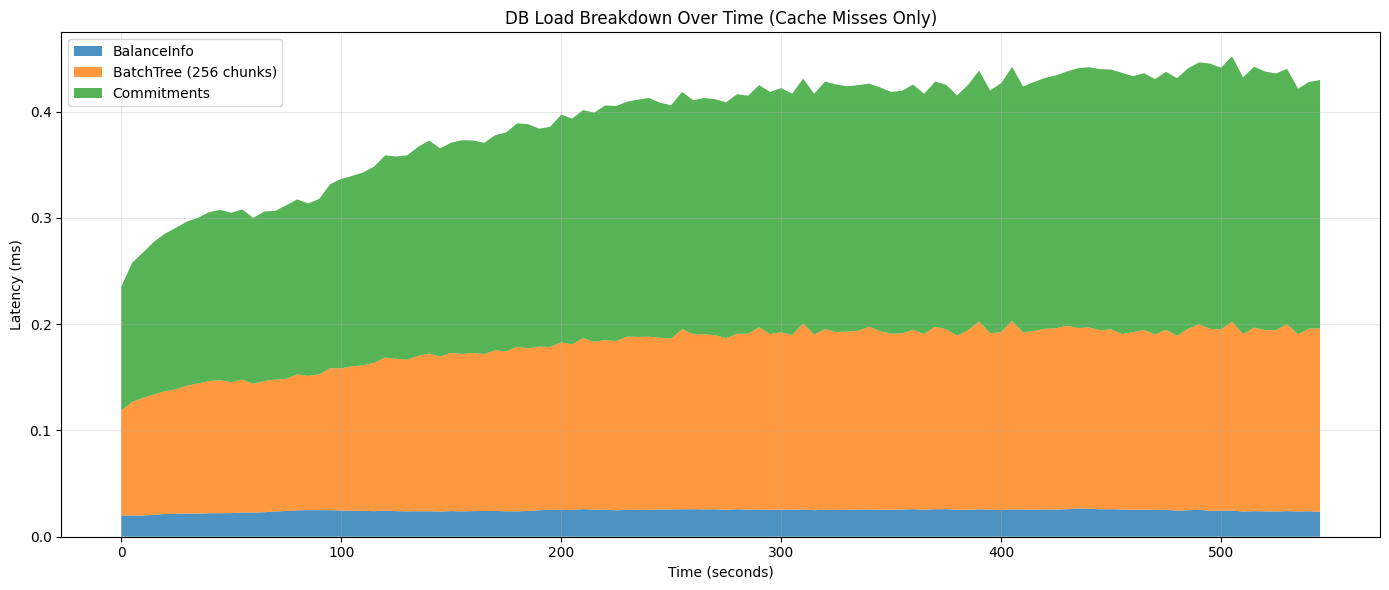

In [ ]:
# DB Load breakdown - only for cache misses
df_miss = df[df["cache_hit"] == 0].copy()
print(f"Cache misses: {len(df_miss)} ({len(df_miss)/len(df)*100:.2f}%)")

if len(df_miss) > 0:
    db_cols = ["load_balance_info_ms", "load_batch_tree_ms", "load_commitments_ms"]
    agg = aggregate_by_window(df_miss, "time_normalized", WINDOW_SECONDS, db_cols)
    
    plt.figure(figsize=(14, 6))
    plt.stackplot(agg["window_start"],
                  agg["load_balance_info_ms"],
                  agg["load_batch_tree_ms"],
                  agg["load_commitments_ms"],
                  labels=["BalanceInfo", "BatchTree (256 chunks)", "Commitments"],
                  alpha=0.8)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Latency (ms)")
    plt.title("DB Load Breakdown Over Time (Cache Misses Only)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No cache misses - all data was in cache")

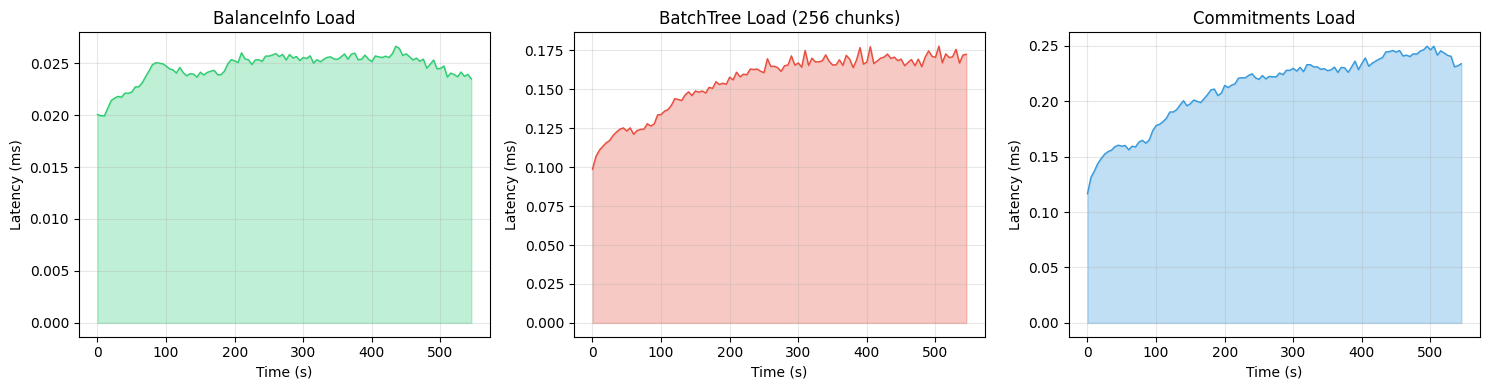

In [ ]:
# Individual DB load components
if len(df_miss) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    components = [
        ("load_balance_info_ms", "BalanceInfo Load", "#2ecc71"),
        ("load_batch_tree_ms", "BatchTree Load (256 chunks)", "#e74c3c"),
        ("load_commitments_ms", "Commitments Load", "#3498db"),
    ]
    
    for idx, (col, title, color) in enumerate(components):
        agg = aggregate_by_window(df_miss, "time_normalized", WINDOW_SECONDS, [col])
        axes[idx].plot(agg["window_start"], agg[col], color=color, linewidth=1)
        axes[idx].fill_between(agg["window_start"], agg[col], alpha=0.3, color=color)
        axes[idx].set_xlabel("Time (s)")
        axes[idx].set_ylabel("Latency (ms)")
        axes[idx].set_title(title)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Mutation Breakdown (Hash + Tree Update)

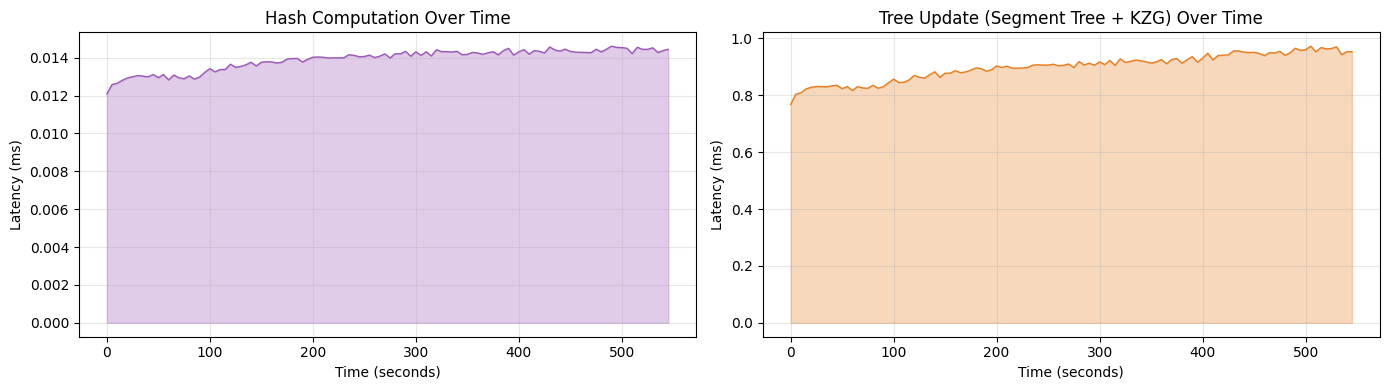

In [ ]:
# Mutation breakdown
mutation_cols = ["hash_ms", "tree_update_ms"]
agg = aggregate_by_window(df, "time_normalized", WINDOW_SECONDS, mutation_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hash timing
axes[0].plot(agg["window_start"], agg["hash_ms"], color="#9b59b6", linewidth=1)
axes[0].fill_between(agg["window_start"], agg["hash_ms"], alpha=0.3, color="#9b59b6")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Hash Computation Over Time")
axes[0].grid(True, alpha=0.3)

# Tree update timing
axes[1].plot(agg["window_start"], agg["tree_update_ms"], color="#e67e22", linewidth=1)
axes[1].fill_between(agg["window_start"], agg["tree_update_ms"], alpha=0.3, color="#e67e22")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("Tree Update (Segment Tree + KZG) Over Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Tree Work Signals (Why Tree Update Degrades)

Has tree-work signals: True


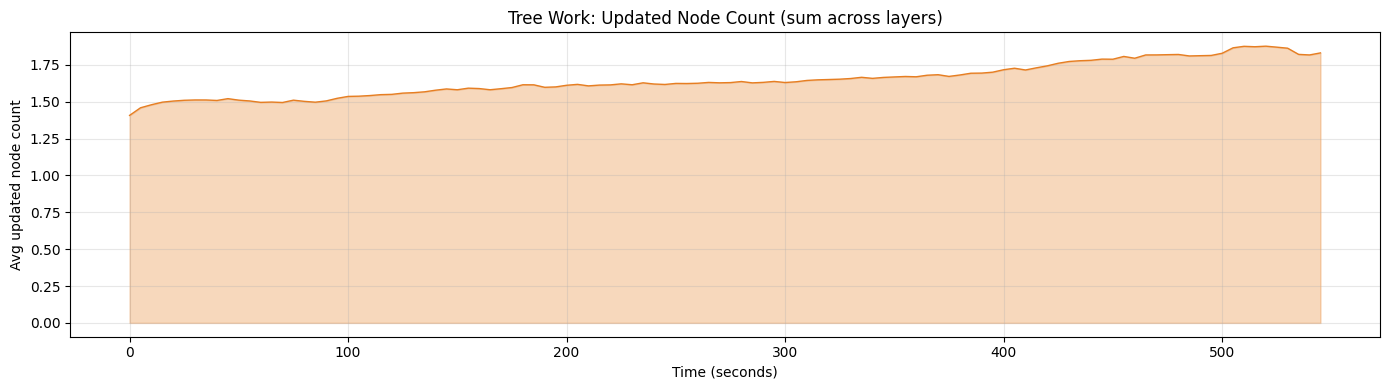

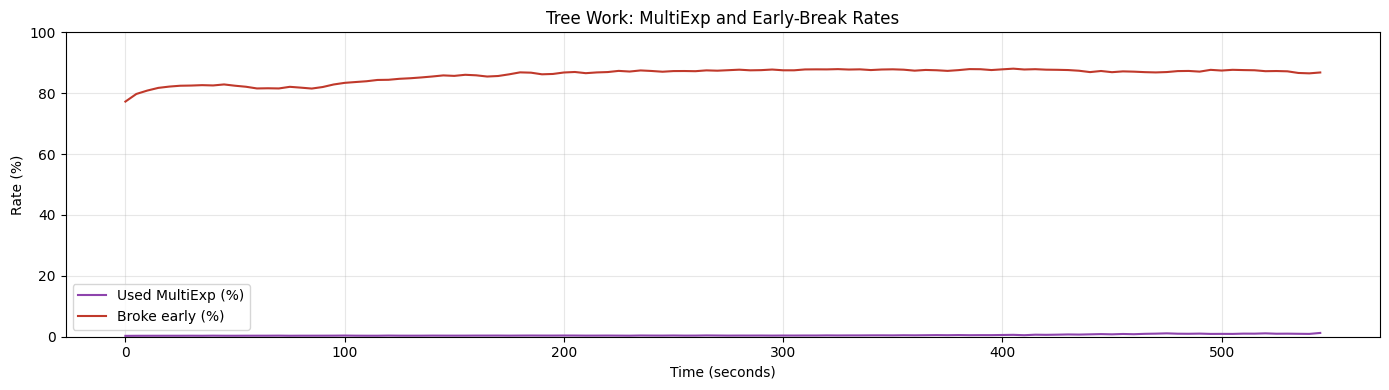

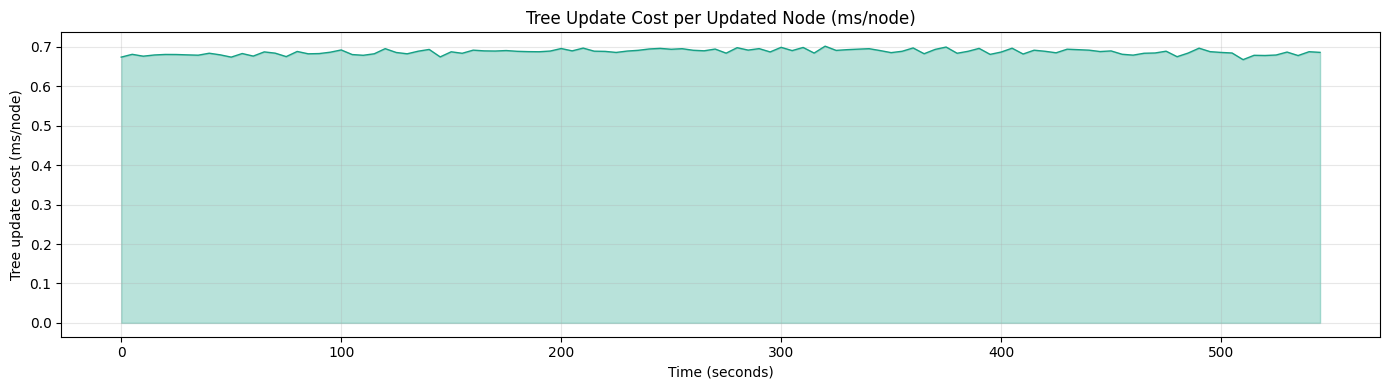

In [ ]:
# These columns exist only for newer runs
has_tree_signals = all(c in df.columns for c in [
    "tree_updated_node_count",
    "tree_used_multiexp",
    "tree_broke_early",
])
print("Has tree-work signals:", has_tree_signals)

if has_tree_signals:
    # Updated node count (avg) over time
    agg_nodes = aggregate_by_window(df, "time_normalized", WINDOW_SECONDS, ["tree_updated_node_count"])
    plt.figure(figsize=(14, 4))
    plt.plot(agg_nodes["window_start"], agg_nodes["tree_updated_node_count"], color="#e67e22", linewidth=1)
    plt.fill_between(agg_nodes["window_start"], agg_nodes["tree_updated_node_count"], alpha=0.3, color="#e67e22")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Avg updated node count")
    plt.title("Tree Work: Updated Node Count (sum across layers)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # MultiExp & broke-early rates over time
    agg_rates = aggregate_by_window(df, "time_normalized", WINDOW_SECONDS, ["tree_used_multiexp", "tree_broke_early"])
    plt.figure(figsize=(14, 4))
    plt.plot(agg_rates["window_start"], agg_rates["tree_used_multiexp"] * 100, label="Used MultiExp (%)", color="#8e44ad")
    plt.plot(agg_rates["window_start"], agg_rates["tree_broke_early"] * 100, label="Broke early (%)", color="#c0392b")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Rate (%)")
    plt.title("Tree Work: MultiExp and Early-Break Rates")
    plt.ylim(0, 100)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Cost per node over time: if this is flat, degradation is 'more work per update'
    if "tree_update_ms_per_node" in df.columns:
        agg_cost = aggregate_by_window(df, "time_normalized", WINDOW_SECONDS, ["tree_update_ms_per_node"])
        plt.figure(figsize=(14, 4))
        plt.plot(agg_cost["window_start"], agg_cost["tree_update_ms_per_node"], color="#16a085", linewidth=1)
        plt.fill_between(agg_cost["window_start"], agg_cost["tree_update_ms_per_node"], alpha=0.3, color="#16a085")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Tree update cost (ms/node)")
        plt.title("Tree Update Cost per Updated Node (ms/node)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
# First vs last window summary for tree-work signals
if has_tree_signals:
    df2 = df.copy()
    df2["window_idx"] = (df2["time_normalized"] // WINDOW_SECONDS).astype(int)
    first_w = df2[df2["window_idx"] == df2["window_idx"].min()]
    last_w = df2[df2["window_idx"] == df2["window_idx"].max()]

    def pct(x):
        return float(np.mean(x) * 100.0)

    first_nodes = float(first_w["tree_updated_node_count"].mean())
    last_nodes = float(last_w["tree_updated_node_count"].mean())
    first_cost = float(np.nanmean(first_w.get("tree_update_ms_per_node", np.nan)))
    last_cost = float(np.nanmean(last_w.get("tree_update_ms_per_node", np.nan)))

    print("=" * 80)
    print("Tree Work Signals: First vs Last Window")
    print("=" * 80)
    print(f"Updated nodes (avg): {first_nodes:.2f} -> {last_nodes:.2f} ({(last_nodes/first_nodes-1)*100:+.1f}% )" if first_nodes > 0 else f"Updated nodes (avg): {first_nodes:.2f} -> {last_nodes:.2f}")
    print(f"Used MultiExp (%):   {pct(first_w['tree_used_multiexp']):.1f}% -> {pct(last_w['tree_used_multiexp']):.1f}%")
    print(f"Broke early (%):     {pct(first_w['tree_broke_early']):.1f}% -> {pct(last_w['tree_broke_early']):.1f}%")
    if not np.isnan(first_cost) and not np.isnan(last_cost) and first_cost > 0:
        print(f"Cost per node (ms):  {first_cost:.4f} -> {last_cost:.4f} ({(last_cost/first_cost-1)*100:+.1f}% )")
    else:
        print(f"Cost per node (ms):  {first_cost} -> {last_cost}")

Tree Work Signals: First vs Last Window
Updated nodes (avg): 1.41 -> 1.83 (+30.1% )
Used MultiExp (%):   0.3% -> 1.2%
Broke early (%):     77.3% -> 86.8%
Cost per node (ms):  0.6742 -> 0.6863 (+1.8% )


## Cache Hit Rate Over Time

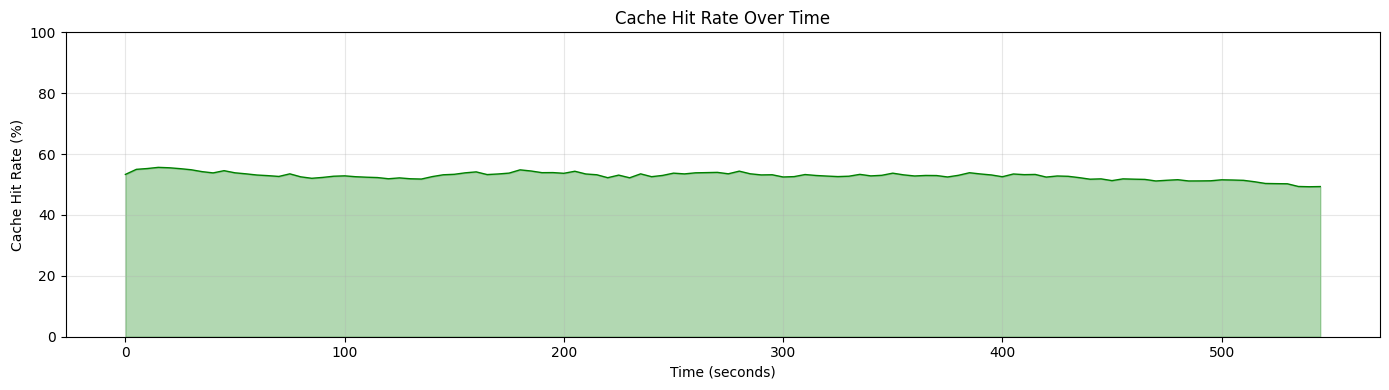

In [ ]:
# Cache hit rate over time
agg = aggregate_by_window(df, "time_normalized", WINDOW_SECONDS, ["cache_hit"])
agg["hit_rate"] = agg["cache_hit"] * 100

plt.figure(figsize=(14, 4))
plt.plot(agg["window_start"], agg["hit_rate"], 'g-', linewidth=1)
plt.fill_between(agg["window_start"], agg["hit_rate"], alpha=0.3, color='green')
plt.xlabel("Time (seconds)")
plt.ylabel("Cache Hit Rate (%)")
plt.title("Cache Hit Rate Over Time")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Latency Comparison: Cache Hit vs Cache Miss

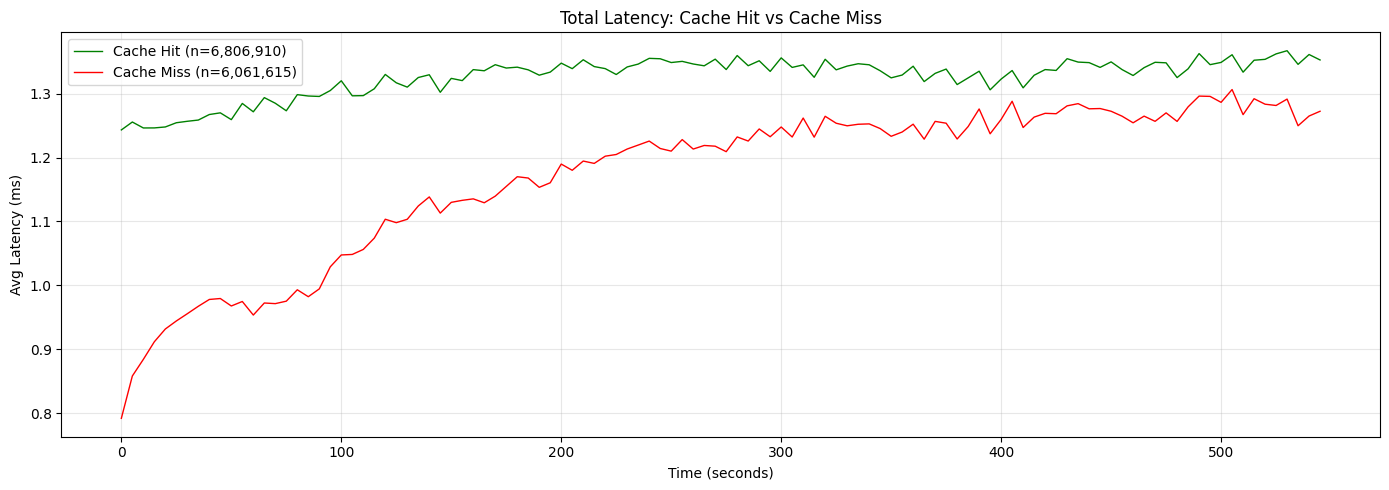

In [ ]:
# Compare cache hit vs miss latency
df_hit = df[df["cache_hit"] == 1].copy()
df_miss = df[df["cache_hit"] == 0].copy()

plt.figure(figsize=(14, 5))

if len(df_hit) > 0:
    agg_hit = aggregate_by_window(df_hit, "time_normalized", WINDOW_SECONDS, ["total_ms"])
    plt.plot(agg_hit["window_start"], agg_hit["total_ms"], 'g-', linewidth=1, label=f"Cache Hit (n={len(df_hit):,})")

if len(df_miss) > 0:
    agg_miss = aggregate_by_window(df_miss, "time_normalized", WINDOW_SECONDS, ["total_ms"])
    plt.plot(agg_miss["window_start"], agg_miss["total_ms"], 'r-', linewidth=1, label=f"Cache Miss (n={len(df_miss):,})")

plt.xlabel("Time (seconds)")
plt.ylabel("Avg Latency (ms)")
plt.title("Total Latency: Cache Hit vs Cache Miss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Statistics

In [ ]:
# Summary statistics
print("=" * 80)
print("Substep Timing Summary (all updates)")
print("=" * 80)

stats_cols = ["total_ms", "cache_lookup_ms", "db_load_total_ms", "init_ms", 
              "mutation_total_ms", "hash_ms", "tree_update_ms", "cache_set_ms"]

for col in stats_cols:
    name = col.replace("_ms", "").replace("_", " ").title()
    print(f"\n{name}:")
    print(f"  Mean:   {df[col].mean():>8.3f} ms")
    print(f"  Median: {df[col].median():>8.3f} ms")
    print(f"  P95:    {df[col].quantile(0.95):>8.3f} ms")
    print(f"  P99:    {df[col].quantile(0.99):>8.3f} ms")
    print(f"  Max:    {df[col].max():>8.3f} ms")

Substep Timing Summary (all updates)

Total:
  Mean:      1.249 ms
  Median:    1.287 ms
  P95:       2.275 ms
  P99:       2.778 ms
  Max:      42.516 ms

Cache Lookup:
  Mean:      0.001 ms
  Median:    0.001 ms
  P95:       0.002 ms
  P99:       0.005 ms
  Max:       4.086 ms

Db Load Total:
  Mean:      0.184 ms
  Median:    0.000 ms
  P95:       0.783 ms
  P99:       0.905 ms
  Max:      41.635 ms

Init:
  Mean:      0.007 ms
  Median:    0.000 ms
  P95:       0.048 ms
  P99:       0.063 ms
  Max:       6.395 ms

Mutation Total:
  Mean:      0.911 ms
  Median:    0.877 ms
  P95:       1.627 ms
  P99:       2.183 ms
  Max:      19.352 ms

Hash:
  Mean:      0.014 ms
  Median:    0.013 ms
  P95:       0.021 ms
  P99:       0.027 ms
  Max:       6.148 ms

Tree Update:
  Mean:      0.896 ms
  Median:    0.862 ms
  P95:       1.606 ms
  P99:       2.162 ms
  Max:      19.333 ms

Cache Set:
  Mean:      0.146 ms
  Median:    0.075 ms
  P95:       0.474 ms
  P99:       0.591 ms
  Max:   

In [ ]:
# DB Load breakdown (cache misses only)
if len(df_miss) > 0:
    print("\n" + "=" * 80)
    print("DB Load Breakdown (Cache Misses Only)")
    print("=" * 80)
    
    db_cols = ["load_balance_info_ms", "load_batch_tree_ms", "load_commitments_ms", "db_load_total_ms"]
    for col in db_cols:
        name = col.replace("_ms", "").replace("load_", "").replace("_", " ").title()
        print(f"\n{name}:")
        print(f"  Mean:   {df_miss[col].mean():>8.3f} ms")
        print(f"  Median: {df_miss[col].median():>8.3f} ms")
        print(f"  P95:    {df_miss[col].quantile(0.95):>8.3f} ms")
        print(f"  Max:    {df_miss[col].max():>8.3f} ms")


DB Load Breakdown (Cache Misses Only)

Balance Info:
  Mean:      0.025 ms
  Median:    0.013 ms
  P95:       0.065 ms
  Max:       8.238 ms

Batch Tree:
  Mean:      0.154 ms
  Median:    0.178 ms
  P95:       0.293 ms
  Max:      41.605 ms

Commitments:
  Mean:      0.210 ms
  Median:    0.320 ms
  P95:       0.531 ms
  Max:      13.923 ms

Db Total:
  Mean:      0.390 ms
  Median:    0.483 ms
  P95:       0.828 ms
  Max:      41.635 ms


In [ ]:
# Percentage breakdown of total latency
print("\n" + "=" * 80)
print("Average Latency Breakdown (% of Total)")
print("=" * 80)

total_mean = df["total_ms"].mean()
components = [
    ("Cache Lookup", df["cache_lookup_ms"].mean()),
    ("DB Load", df["db_load_total_ms"].mean()),
    ("Init", df["init_ms"].mean()),
    ("Mutation", df["mutation_total_ms"].mean()),
    ("Cache Set", df["cache_set_ms"].mean()),
]

for name, val in components:
    pct = (val / total_mean) * 100 if total_mean > 0 else 0
    bar = "█" * int(pct / 2)
    print(f"{name:<15}: {val:>7.3f} ms ({pct:>5.1f}%) {bar}")


Average Latency Breakdown (% of Total)
Cache Lookup   :   0.001 ms (  0.1%) 
DB Load        :   0.184 ms ( 14.7%) ███████
Init           :   0.007 ms (  0.6%) 
Mutation       :   0.911 ms ( 72.9%) ████████████████████████████████████
Cache Set      :   0.146 ms ( 11.7%) █████
